In [1]:
#pip install scikeras

In [2]:
#pip install scikit-learn==0.24.2 scikeras==0.8.0

In [3]:
#pip install --upgrade scikit-learn scikeras

### Importing Libraries

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, AdaBoostClassifier,VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import StackingClassifier


### Data Preprocessing

In [35]:
df=pd.read_csv("Dyt-desktop.csv",sep=';')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [36]:
df.head()

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,Clicks2,Hits2,Misses2,Score2,Accuracy2,Missrate2,Clicks3,Hits3,Misses3,Score3,Accuracy3,Missrate3,Clicks4,Hits4,Misses4,Score4,Accuracy4,Missrate4,Clicks5,Hits5,Misses5,Score5,Accuracy5,Missrate5,Clicks6,Hits6,Misses6,Score6,Accuracy6,Missrate6,Clicks7,Hits7,Misses7,Score7,Accuracy7,Missrate7,Clicks8,Hits8,Misses8,Score8,Accuracy8,Missrate8,Clicks9,Hits9,Misses9,Score9,Accuracy9,Missrate9,Clicks10,Hits10,Misses10,Score10,Accuracy10,Missrate10,Clicks11,Hits11,Misses11,Score11,Accuracy11,Missrate11,Clicks12,Hits12,Misses12,Score12,Accuracy12,Missrate12,Clicks13,Hits13,Misses13,Score13,Accuracy13,Missrate13,Clicks14,Hits14,Misses14,Score14,Accuracy14,Missrate14,Clicks15,Hits15,Misses15,Score15,Accuracy15,Missrate15,Clicks16,Hits16,Misses16,Score16,Accuracy16,Missrate16,Clicks17,Hits17,Misses17,Score17,Accuracy17,Missrate17,Clicks18,Hits18,Misses18,Score18,Accuracy18,Missrate18,Clicks19,Hits19,Misses19,Score19,Accuracy19,Missrate19,Clicks20,Hits20,Misses20,Score20,Accuracy20,Missrate20,Clicks21,Hits21,Misses21,Score21,Accuracy21,Missrate21,Clicks22,Hits22,Misses22,Score22,Accuracy22,Missrate22,Clicks23,Hits23,Misses23,Score23,Accuracy23,Missrate23,Clicks24,Hits24,Misses24,Score24,Accuracy24,Missrate24,Clicks25,Hits25,Misses25,Score25,Accuracy25,Missrate25,Clicks26,Hits26,Misses26,Score26,Accuracy26,Missrate26,Clicks27,Hits27,Misses27,Score27,Accuracy27,Missrate27,Clicks28,Hits28,Misses28,Score28,Accuracy28,Missrate28,Clicks29,Hits29,Misses29,Score29,Accuracy29,Missrate29,Clicks30,Hits30,Misses30,Score30,Accuracy30,Missrate30,Clicks31,Hits31,Misses31,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,No,Yes,7,10,10,0,10,1.0,0.0,5,5,0,5,1.0,0.0,6,6,0,6,1.0,0.0,2,2,0,2,1.0,0.0,3,3,0,3,1.0,0.0,4,1,3,1,0.25,0.75,5,5,0,5,1.000000,0.000000,4,3,1,3,0.750000,0.250000,1,0,1,0,0.0,1.0,1,1,0,1,1.000000,0.000000,3,1,2,1,0.333333,0.666667,3,3,0,3,1.0,0.0,3,3,0,3,1.0,0.0,4,4,0,4,1.0,0.0,2,2,0,2,1.0,0.0,2,2,0,2,1.0,0.0,3,3,0,3,1.0,0.0,2,2,0,2,1.00,0.00,4,3,1,3,0.750000,0.250000,5,1,4,1,0.200000,0.800000,3,1,2,1,0.333333,0.666667,4,1,3,1,0.250000,0.750000,4,3,1,3,0.750000,0.250000,3,2,1,2,0.666667,0.333333,3,3,0,3,1.0,0.0,5,3,2,3,0.600000,0.400000,9,1,1,1,0.111111,0.111111,6,2,0,2,0.333333,0.000000,4,1,1,1,0.25,0.25,14,1,2,1,0.071429,0.142857,18,0,0,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,No
1,Female,Yes,Yes,13,12,12,0,12,1.0,0.0,11,11,0,11,1.0,0.0,10,10,0,10,1.0,0.0,4,4,0,4,1.0,0.0,5,5,0,5,1.0,0.0,5,5,0,5,1.00,0.00,5,4,1,4,0.800000,0.200000,6,5,1,5,0.833333,0.166667,5,4,1,4,0.8,0.2,10,10,0,10,1.000000,0.000000,5,4,1,4,0.800000,0.200000,5,5,0,5,1.0,0.0,4,4,0,4,1.0,0.0,10,10,0,10,1.0,0.0,5,5,0,5,1.0,0.0,4,4,0,4,1.0,0.0,4,4,0,4,1.0,0.0,4,3,1,3,0.75,0.25,8,3,5,3,375.000000,625.000000,3,1,2,1,0.333333,0.666667,3,1,2,1,0.333333,0.666667,9,7,2,7,0.777778,0.222222,6,5,1,5,0.833333,0.166667,3,2,1,2,0.666667,0.333333,5,5,0,5,1.0,0.0,12,8,4,8,0.666667,0.333333,16,2,1,2,125.000000,0.062500,9,2,1,2,0.222222,0.111111,5,0,2,0,0.00,0.40,17,2,2,2,0.117647,0.117647,35,4,0,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,Yes
2,Female,No,Yes,7,6,6,0,6,1.0,0.0,6,6,0,6,1.0,0.0,6,6,0,6,1.0,0.0,3,3,0,3,1.0,0.0,4,4,0,4,1.0,0.0,2,2,0,2,1.00,0.00,7,5,2,5,0.714286,0.285714,5,3,2,3,0.600000,0.400000,3,3,0,3,1.0,0.0,7,5,2,5,0.714286,0.285714,6,5,1,5,0.833333,0.166667,6,6,0,6,1.0,0.0,3,3,0,3,1.0,0.0,6,6,0,6,1.0,0.0,3,3,0,3,1.0,0.0,4,4,0,4,1.0,0.0,2,2,0,2,1.0,0.0,2,1,1,1,0.50,0.50,5,4,1,4,0.800000,0.200000,6,1,5,1,0.166667,0.833333,6,3,3,3,0.500000,0.500000,6,5,1,5,0.833333,0.166667,5,3,2,3,0.600000,0.400000,4,3,1,3,0.750000,0.250000,5,4,1,4,0.8,0.2,5,2,3,2,0.400000,0.600000,17,2,1,2,0.117647,0.058824,13,3,1,3,0.230769,0.076923,5,0,2,0,0.00,0.40,17,1,3,1,0.058824,0.176471,35,4,0,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,No
3,Female,No,Yes,7,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0,1,1,0,1,1.0,0.0,0,0,0,0,0.0,0.0,2,1,1,1,0.5,0.5,0,0,0,0,0.00,0.00,4,0,4,0,0.000

In [37]:
df.describe()

,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,Clicks2,Hits2,Misses2,Score2,Accuracy2,Missrate2,Clicks3,Hits3,Misses3,Score3,Accuracy3,Missrate3,Clicks4,Hits4,Misses4,Score4,Accuracy4,Missrate4,Clicks5,Hits5,Misses5,Score5,Accuracy5,Missrate5,Clicks6,Hits6,Misses6,Score6,Accuracy6,Missrate6,Clicks7,Hits7,Misses7,Score7,Accuracy7,Missrate7,Clicks8,Hits8,Misses8,Score8,Accuracy8,Missrate8,Clicks9,Hits9,Misses9,Score9,Accuracy9,Missrate9,Clicks10,Hits10,Misses10,Score10,Accuracy10,Missrate10,Clicks11,Hits11,Misses11,Score11,Accuracy11,Missrate11,Clicks12,Hits12,Misses12,Score12,Accuracy12,Missrate12,Clicks13,Hits13,Misses13,Score13,Accuracy13,Missrate13,Clicks14,Hits14,Misses14,Score14,Accuracy14,Missrate14,Clicks15,Hits15,Misses15,Score15,Accuracy15,Missrate15,Clicks16,Hits16,Misses16,Score16,Accuracy16,Missrate16,Clicks17,Hits17,Misses17,Score17,Accuracy17,Missrate17,Clicks18,Hits18,Misses18,Score18,Accuracy18,Missrate18,Clicks19,Hits19,Misses19,Score19,Accuracy19,Missrate19,Clicks20,Hits20,Misses20,Score20,Accuracy20,Missrate20,Clicks21,Hits21,Misses21,Score21,Accuracy21,Missrate21,Clicks22,Hits22,Misses22,Score22,Accuracy22,Missrate22,Clicks23,Hits23,Misses23,Score23,Accuracy23,Missrate23,Clicks24,Hits24,Misses24,Score24,Accuracy24,Missrate24,Clicks25,Hits25,Misses25,Score25,Accuracy25,Missrate25,Clicks26,Hits26,Misses26,Score26,Accuracy26,Missrate26,Clicks27,Hits27,Misses27,Score27,Accuracy27,Missrate27,Clicks28,Hits28,Misses28,Score28,Accuracy28,Missrate28,Clicks29,Hits29,Misses29,Score29,Accuracy29,Missrate29,Clicks30,Hits30,Misses30,Score30,Accuracy30,Missrate30,Clicks31,Hits31,Misses31,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32
count,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,3644.000000,364

In [38]:
df.isnull().sum().sum()

np.int64(0)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Columns: 197 entries, Gender to Dyslexia
dtypes: float64(64), int64(129), object(4)
memory usage: 5.5+ MB


In [40]:
def strtoint(data) :    
    data['Gender']=data.Gender.map({'Male': 1, 'Female': 2})
    data['Dyslexia']=data.Dyslexia.map({'No': 0, 'Yes': 1})
    data['Nativelang']=data.Nativelang.map({'No': 0, 'Yes': 1})
    data['Otherlang']=data.Otherlang.map({'No': 0, 'Yes': 1})

In [41]:
strtoint(df)

In [42]:
df.head()

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,Clicks2,Hits2,Misses2,Score2,Accuracy2,Missrate2,Clicks3,Hits3,Misses3,Score3,Accuracy3,Missrate3,Clicks4,Hits4,Misses4,Score4,Accuracy4,Missrate4,Clicks5,Hits5,Misses5,Score5,Accuracy5,Missrate5,Clicks6,Hits6,Misses6,Score6,Accuracy6,Missrate6,Clicks7,Hits7,Misses7,Score7,Accuracy7,Missrate7,Clicks8,Hits8,Misses8,Score8,Accuracy8,Missrate8,Clicks9,Hits9,Misses9,Score9,Accuracy9,Missrate9,Clicks10,Hits10,Misses10,Score10,Accuracy10,Missrate10,Clicks11,Hits11,Misses11,Score11,Accuracy11,Missrate11,Clicks12,Hits12,Misses12,Score12,Accuracy12,Missrate12,Clicks13,Hits13,Misses13,Score13,Accuracy13,Missrate13,Clicks14,Hits14,Misses14,Score14,Accuracy14,Missrate14,Clicks15,Hits15,Misses15,Score15,Accuracy15,Missrate15,Clicks16,Hits16,Misses16,Score16,Accuracy16,Missrate16,Clicks17,Hits17,Misses17,Score17,Accuracy17,Missrate17,Clicks18,Hits18,Misses18,Score18,Accuracy18,Missrate18,Clicks19,Hits19,Misses19,Score19,Accuracy19,Missrate19,Clicks20,Hits20,Misses20,Score20,Accuracy20,Missrate20,Clicks21,Hits21,Misses21,Score21,Accuracy21,Missrate21,Clicks22,Hits22,Misses22,Score22,Accuracy22,Missrate22,Clicks23,Hits23,Misses23,Score23,Accuracy23,Missrate23,Clicks24,Hits24,Misses24,Score24,Accuracy24,Missrate24,Clicks25,Hits25,Misses25,Score25,Accuracy25,Missrate25,Clicks26,Hits26,Misses26,Score26,Accuracy26,Missrate26,Clicks27,Hits27,Misses27,Score27,Accuracy27,Missrate27,Clicks28,Hits28,Misses28,Score28,Accuracy28,Missrate28,Clicks29,Hits29,Misses29,Score29,Accuracy29,Missrate29,Clicks30,Hits30,Misses30,Score30,Accuracy30,Missrate30,Clicks31,Hits31,Misses31,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,1,0,1,7,10,10,0,10,1.0,0.0,5,5,0,5,1.0,0.0,6,6,0,6,1.0,0.0,2,2,0,2,1.0,0.0,3,3,0,3,1.0,0.0,4,1,3,1,0.25,0.75,5,5,0,5,1.000000,0.000000,4,3,1,3,0.750000,0.250000,1,0,1,0,0.0,1.0,1,1,0,1,1.000000,0.000000,3,1,2,1,0.333333,0.666667,3,3,0,3,1.0,0.0,3,3,0,3,1.0,0.0,4,4,0,4,1.0,0.0,2,2,0,2,1.0,0.0,2,2,0,2,1.0,0.0,3,3,0,3,1.0,0.0,2,2,0,2,1.00,0.00,4,3,1,3,0.750000,0.250000,5,1,4,1,0.200000,0.800000,3,1,2,1,0.333333,0.666667,4,1,3,1,0.250000,0.750000,4,3,1,3,0.750000,0.250000,3,2,1,2,0.666667,0.333333,3,3,0,3,1.0,0.0,5,3,2,3,0.600000,0.400000,9,1,1,1,0.111111,0.111111,6,2,0,2,0.333333,0.000000,4,1,1,1,0.25,0.25,14,1,2,1,0.071429,0.142857,18,0,0,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,0
1,2,1,1,13,12,12,0,12,1.0,0.0,11,11,0,11,1.0,0.0,10,10,0,10,1.0,0.0,4,4,0,4,1.0,0.0,5,5,0,5,1.0,0.0,5,5,0,5,1.00,0.00,5,4,1,4,0.800000,0.200000,6,5,1,5,0.833333,0.166667,5,4,1,4,0.8,0.2,10,10,0,10,1.000000,0.000000,5,4,1,4,0.800000,0.200000,5,5,0,5,1.0,0.0,4,4,0,4,1.0,0.0,10,10,0,10,1.0,0.0,5,5,0,5,1.0,0.0,4,4,0,4,1.0,0.0,4,4,0,4,1.0,0.0,4,3,1,3,0.75,0.25,8,3,5,3,375.000000,625.000000,3,1,2,1,0.333333,0.666667,3,1,2,1,0.333333,0.666667,9,7,2,7,0.777778,0.222222,6,5,1,5,0.833333,0.166667,3,2,1,2,0.666667,0.333333,5,5,0,5,1.0,0.0,12,8,4,8,0.666667,0.333333,16,2,1,2,125.000000,0.062500,9,2,1,2,0.222222,0.111111,5,0,2,0,0.00,0.40,17,2,2,2,0.117647,0.117647,35,4,0,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,1
2,2,0,1,7,6,6,0,6,1.0,0.0,6,6,0,6,1.0,0.0,6,6,0,6,1.0,0.0,3,3,0,3,1.0,0.0,4,4,0,4,1.0,0.0,2,2,0,2,1.00,0.00,7,5,2,5,0.714286,0.285714,5,3,2,3,0.600000,0.400000,3,3,0,3,1.0,0.0,7,5,2,5,0.714286,0.285714,6,5,1,5,0.833333,0.166667,6,6,0,6,1.0,0.0,3,3,0,3,1.0,0.0,6,6,0,6,1.0,0.0,3,3,0,3,1.0,0.0,4,4,0,4,1.0,0.0,2,2,0,2,1.0,0.0,2,1,1,1,0.50,0.50,5,4,1,4,0.800000,0.200000,6,1,5,1,0.166667,0.833333,6,3,3,3,0.500000,0.500000,6,5,1,5,0.833333,0.166667,5,3,2,3,0.600000,0.400000,4,3,1,3,0.750000,0.250000,5,4,1,4,0.8,0.2,5,2,3,2,0.400000,0.600000,17,2,1,2,0.117647,0.058824,13,3,1,3,0.230769,0.076923,5,0,2,0,0.00,0.40,17,1,3,1,0.058824,0.176471,35,4,0,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,0
3,2,0,1,7,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0,1,1,0,1,1.0,0.0,0,0,0,0,0.0,0.0,2,1,1,1,0.5,0.5,0,0,0,0,0.00,0.00,4,0,4,0,0.000000,1.000000,2,0,2,0,0.000000,1.000

In [43]:
df.shape

(3644, 197)

In [44]:
X = df.loc[:,:'Missrate32']
y = df['Dyslexia']

In [45]:
X.shape

(3644, 196)

In [46]:
y.shape

(3644,)

### Data Splitting

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [49]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

## Model - 1 
### Voting Classifier

In [50]:
models = [
    ('gb', GradientBoostingClassifier()),
    ('svc', SVC(probability=True)),
    ('ada', AdaBoostClassifier())
]

voting_clf = VotingClassifier(estimators=models, voting='soft')
voting_clf.fit(X_train_processed, y_train)

C:\Users\intel 3\SoftwareFol\envs\proj4\lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


VotingClassifier(estimators=[('gb', GradientBoostingClassifier()),
                             ('svc', SVC(probability=True)),
                             ('ada', AdaBoostClassifier())],
                 voting='soft')

In [51]:
y_pred=voting_clf.predict(X_test_processed)

In [52]:
print(accuracy_score(y_test,y_pred)*100)

91.90672153635117


In [31]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Assuming y_test contains the true labels and y_pred contains the predicted labels
f1 = f1_score(y_test, y_pred) * 100  # Multiply by 100 for percentage
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100

# Print the results
print(f"F1 Score: {f1:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")


F1 Score: 95.58%
Precision: 98.18%
Recall: 99.90%


### Confusion Matrix

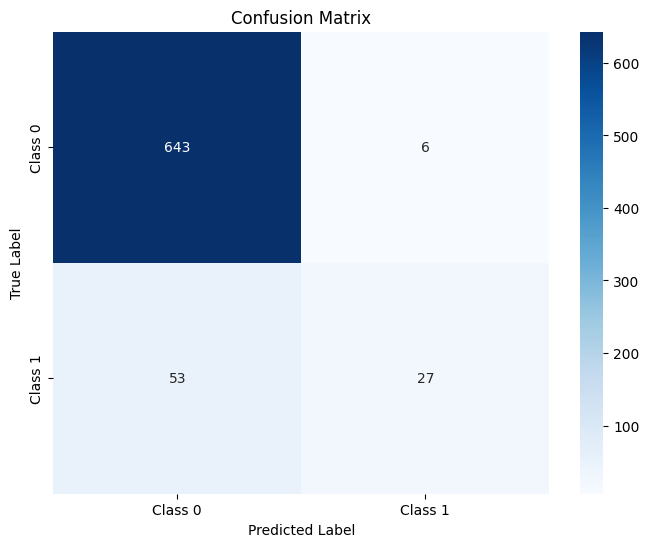

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


### ROC Curve

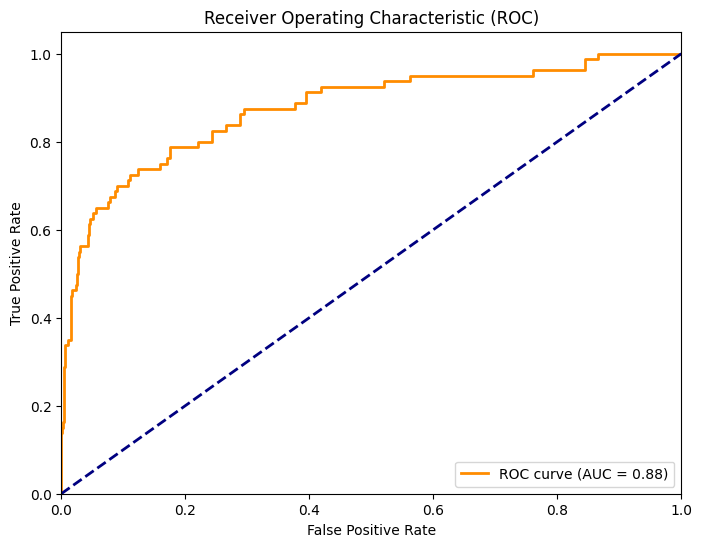

In [124]:
from sklearn.metrics import roc_curve, auc

# Get the predicted probabilities
y_proba = voting_clf.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


### Precision-Recall Curve

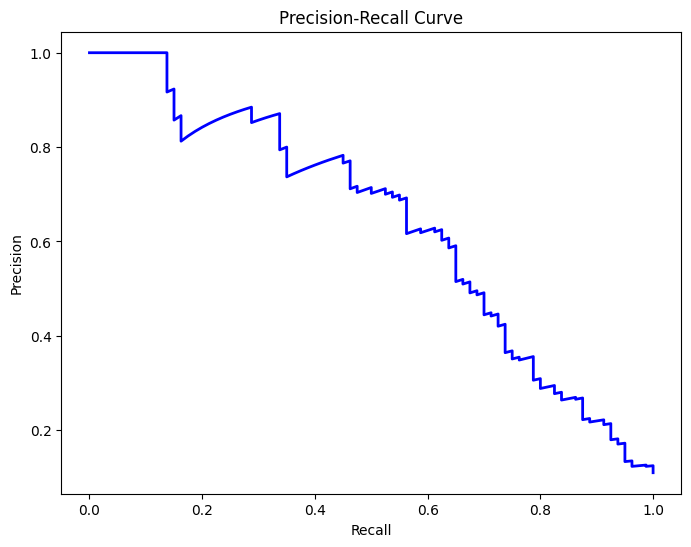

In [125]:
from sklearn.metrics import precision_recall_curve

# Compute precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Plot precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


### Learning Curve

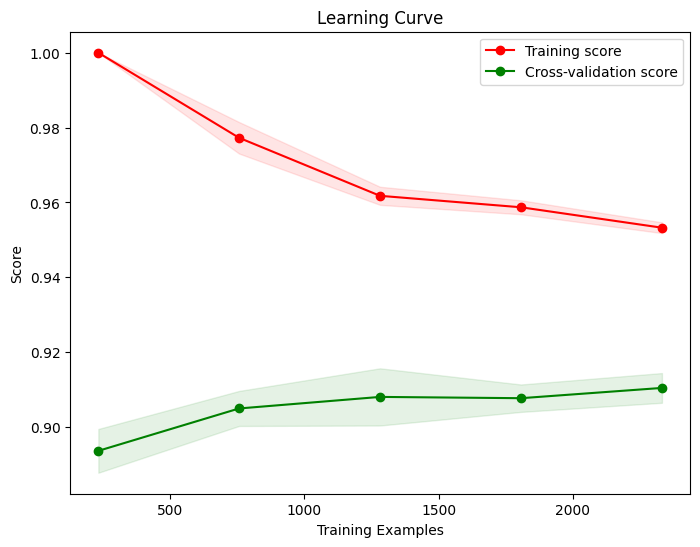

In [126]:
from sklearn.model_selection import learning_curve

# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(voting_clf, X_train_processed, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Compute mean and standard deviation
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.title('Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.legend(loc="best")
plt.show()


In [128]:

if len(y_test) != len(y_pred):
    print("Error: y_test and y_pred must have the same number of entries.")
else:
    # Finding rows predicted as 1 and 0
    predicted_as_1 = []
    predicted_as_0 = []

    for idx in range(len(y_pred)):
        if y_pred[idx] == 1:
            predicted_as_1.append((y_test.index[idx], y_test.iloc[idx]))  # Store (row number, actual value) for predicted 1
        else:
            predicted_as_0.append((y_test.index[idx], y_test.iloc[idx]))  # Store (row number, actual value) for predicted 0

    # Displaying rows predicted as 1
    print("\nRows predicted as 1 (row number, y_test value):")
    for row in predicted_as_1:
        print(f"Row {row[0]}: y_test = {row[1]}")  # Accessing row number and actual value

    # Displaying rows predicted as 0
    print("\nRows predicted as 0 (row number, y_test value):")
    for row in predicted_as_0:
        print(f"Row {row[0]}: y_test = {row[1]}")


Rows predicted as 1 (row number, y_test value):
Row 315: y_test = 1
Row 3442: y_test = 1
Row 1113: y_test = 1
Row 3474: y_test = 1
Row 3464: y_test = 1
Row 3455: y_test = 1
Row 3446: y_test = 1
Row 2624: y_test = 1
Row 139: y_test = 0
Row 3404: y_test = 0
Row 670: y_test = 1
Row 2645: y_test = 1
Row 2871: y_test = 0
Row 2375: y_test = 1
Row 1350: y_test = 1
Row 599: y_test = 1
Row 2699: y_test = 1
Row 3468: y_test = 1
Row 2606: y_test = 1
Row 3466: y_test = 0
Row 3197: y_test = 0
Row 14: y_test = 1
Row 3503: y_test = 1
Row 3420: y_test = 1
Row 3502: y_test = 1
Row 371: y_test = 1
Row 2299: y_test = 1
Row 2621: y_test = 1
Row 3453: y_test = 1
Row 3427: y_test = 1
Row 3414: y_test = 0
Row 3434: y_test = 1
Row 2663: y_test = 1

Rows predicted as 0 (row number, y_test value):
Row 415: y_test = 0
Row 2927: y_test = 1
Row 3194: y_test = 0
Row 298: y_test = 0
Row 1874: y_test = 0
Row 2691: y_test = 0
Row 32: y_test = 0
Row 3313: y_test = 0
Row 2629: y_test = 1
Row 2897: y_test = 0
Row 657: y

### Model Saving

In [129]:
import pickle as pkl

with open('model1.pkl','wb') as file:
    pkl.dump(voting_clf,file)

In [130]:
with open('pipeline.pkl', 'wb') as file:
    pkl.dump(pipeline, file)

## Model - 2
### Existing Model

In [131]:
import pandas as pd
import numpy as np
import csv
from sklearn.model_selection import train_test_split
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from deap import base, creator, tools, algorithms
from sklearn.neighbors import KNeighborsClassifier 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define machine learning models
models = {
    'sv': KNeighborsClassifier(n_neighbors=5),
    'dt': DecisionTreeClassifier(),
    'lr': LogisticRegression(max_iter=1000)
}

# Train all models
for model in models.values():
    model.fit(X_train, y_train)

    # Define the evaluation function for the genetic algorithm
def evaluate(individual):
    weights = np.array(individual)
    predictions = np.zeros((X_test.shape[0], len(models)))
    
    # Collect predictions from each model
    for i, (name, model) in enumerate(models.items()):
        predictions[:, i] = model.predict_proba(X_test)[:, 1]
    
    # Combine predictions using the individual weights
    weighted_predictions = np.dot(predictions, weights)
    predicted_classes = np.round(weighted_predictions).astype(int)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, predicted_classes)
    return (accuracy,)


# Set up the genetic algorithm
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.uniform, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=len(models))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutPolynomialBounded, low=0, up=1, eta=1.0, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Create population
population = toolbox.population(n=50)

# Run the genetic algorithm
algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=10, verbose=True)

# Extract the best individual
best_individual = tools.selBest(population, 1)[0]
print(f"Best individual is {best_individual} with fitness {evaluate(best_individual)}")


# Evaluate the best model on the test set
weights = np.array(best_individual)
predictions = np.zeros((X_test.shape[0], len(models)))

# Collect predictions from each model
for i, (name, model) in enumerate(models.items()):
    predictions[:, i] = model.predict_proba(X_test)[:, 1]

# Combine predictions using the best individual weights
weighted_predictions = np.dot(predictions, weights)
predicted_classes = np.round(weighted_predictions).astype(int)
accuracy = accuracy_score(y_test, predicted_classes)
print(f"Test Accuracy with optimized weights: {accuracy:}")

C:\Users\intel 3\SoftwareFol\envs\proj4\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\intel 3\SoftwareFol\envs\proj4\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\intel 3\SoftwareFol\envs\proj4\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be

gen	nevals
0  	50    
1  	31    
2  	34    
3  	35    
4  	32    
5  	31    
6  	25    
7  	26    
8  	36    
9  	31    
10 	23    
Best individual is [0.6188470740129611, 0.05340483266946096, 0.408171887463501] with fitness (0.9104204753199269,)
Test Accuracy with optimized weights: 0.9104204753199269


## Testing


In [102]:
d=[[]]

x=pipeline.transform(d)
x

C:\Users\intel 3\SoftwareFol\envs\proj4\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


array([[ 1.01555841e+00,  1.68991719e+00,  4.84403072e-01,
         1.00654128e+00,  1.06038339e+00,  1.74015781e+00,
        -7.01323295e-01,  1.73355815e+00, -5.90331311e-02,
        -1.20162368e-01,  7.32023202e-02,  1.39748749e+00,
        -4.98080145e-01,  1.35557507e+00, -7.18156013e-02,
        -9.97818286e-02, -1.93812121e-01,  1.60697393e+00,
        -5.32663035e-01,  1.55810372e+00, -7.55556429e-02,
        -9.58767921e-02, -8.48245705e-01, -4.95896922e-01,
        -7.41041180e-01, -4.93107020e-01, -1.73086700e-01,
        -1.69208753e-01, -2.93084839e-04,  6.23210576e-01,
        -2.30714002e-01,  5.74754545e-01, -1.13995293e-01,
        -9.76089446e-02,  3.43112051e-04, -2.42864630e-01,
         2.97066655e-01, -2.45610639e-01, -1.22830114e-01,
        -8.77808344e-02,  2.57129411e-01,  1.47623425e-01,
         2.91038611e-01,  1.40489675e-01, -1.74201995e-01,
        -1.49888573e-01,  8.11933352e-01,  1.83017924e+00,
        -3.36881002e-01,  1.82026211e+00, -1.25164592e-0

In [103]:
voting_clf.predict(x)

array([1])